# Cars4You - Handout Project | Group 42
## Notebook 1 — Models Lab
**Course:** MSc in Data Science and Advanced Analytics, NOVA IMS (2025/2026)  

**Author(s):** Group 42
- `Miguel Matos - 20221925`
- `Andre Nicolau - 20221918`
- `André Ferreira - 20250398`


---

#### <font> Table of Contents </font> <a class="anchor" id='toc'></a> 
1. [Imports](#Imports)  
2. [Modelling Testing](#modelling-testing) 
3. [Random Search](#random-search)
----

# Imports
[Back to TOC](#toc)

In [ ]:
from utils.functions import *
from utils.Nuestra_Pipeline import NuestraPipeline
from Preprocessing_pipelines.Outliers_pipeline import OutliersDealer
from Preprocessing_pipelines.Missing_Values_pipeline import MissingValuesDealer
from Preprocessing_pipelines.Encoding_pipeline import EncodingDealer
from Preprocessing_pipelines.Scaling_pipeline import ScalingDealer
from Preprocessing_pipelines.Feature_Selection_pipeline import FeatureSelectionDealer
import warnings

# Suppress this specific warning
warnings.filterwarnings('ignore', 
                       message='X does not have valid feature names',
                       category=UserWarning,
                       module='sklearn.utils.validation')

data = pd.read_csv("../data/data_cleaned.csv", index_col= "carID")
pd.set_option("display.max_columns", None)

In [ ]:
data = data.sample(frac=1).reset_index(drop=True)

As the objective is to create a predictive model that is accurate without the need of the mechanic's assessment, we'll drop the "paintQuality%" column.

In [ ]:
data.drop("paintQuality%", axis = 1, inplace= True)

In [ ]:
X = data.drop("price", axis= 1)
y = data["price"]

# Random Search

In [ ]:
rf = RandomForestRegressor()

pipeline = NuestraPipeline(MissingValuesDealer(),
                           OutliersDealer(),
                           EncodingDealer(), 
                           ScalingDealer(),
                           FeatureSelectionDealer(),
                           rf)

parameters = {
    
    # Random Forest
    
              "imputer__imputation_method": ["knn_modelwise","simple"],
              "imputer__knn_neighbors": np.arange(15,21),
              "imputer__knn_scaling_method" : ["standard", "minmax", "robust"],
              "outlier_remover__outlier_method" : ["IQR"],
              "outlier_remover__mod_outliers_cols" : [["car_age", "mileage", "tax", "mpg"], ["tax", "mpg"]],
              "outlier_remover__sev_outliers_cols" : [["car_age", "mileage", "engineSize"], ["car_age", "mileage"]],
              "outlier_remover__threshold" : [2,3],
              "outlier_remover__z_columns" : [["car_age", "mileage", "tax", "mpg"]],
              "outlier_remover__log_columns" : [["car_age", "mileage", "tax", "mpg", "engineSize"]],
              "outlier_remover__contamination_IF" : [0.15, 0.3, 0.5],
              "outlier_remover__n_neighbors": [30, 50, 70],
              "outlier_remover__contamination_LOF" : [0.15, 0.3, 0.5],
              "outlier_remover__model_columns" : [["car_age", "mileage", "tax", "mpg"], ["car_age", "mileage", "tax", "mpg", "engineSize"]],
              "encoder__method" : ["target"],
              "scaler__scaler_name" : ["robust", "minmax", "standard"],
              "selector__selection_method": ["kbest", "model", "rfe"],
              "selector__k": np.arange(10,25),
              "selector__model_name" : ["rf"],
              "selector__n_features_to_select": np.arange(10,25),
              "model": [rf],
              "model__criterion" : ["squared_error", "absolute_error", "friedman_mse", "poisson"],
              "model__n_estimators" : np.arange(100, 130, 10),
              "model__max_depth": np.arange(10, 50, 5),
              "model__max_features" : ['sqrt', 'log2', 0.5, 0.8, 1.0],
              "model__min_impurity_decrease" : [0.2, 0.3, 0.5],
              "model__min_samples_split" : np.arange(2, 200, 15),
              "model__max_samples" : [0.3, 0.5, 0.8, None],
              "model__min_samples_leaf" : np.arange(15, 70, 5)
}

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

random_search = RandomizedSearchCV(pipeline, parameters, 
                                      n_iter= 50,
                                      scoring= mae_scorer, 
                                      verbose = 3, 
                                      refit = "mae_scorer",
                                      cv = 5, 
                                      n_jobs= 4)

In [ ]:
random_search.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=10. All the features will be returned.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=10. All the features will be returned.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=10. All the features will be returned.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=10. All the features will be returned.
  warnings.warn(


[CV 3/5] END encoder__method=target, imputer__imputation_method=knn_modelwise, imputer__knn_neighbors=19, imputer__knn_scaling_method=standard, model=RandomForestRegressor(), model__criterion=friedman_mse, model__max_depth=45, model__max_features=sqrt, model__max_samples=0.8, model__min_impurity_decrease=0.5, model__min_samples_leaf=25, model__min_samples_split=122, model__n_estimators=110, outlier_remover__contamination_IF=0.3, outlier_remover__contamination_LOF=0.3, outlier_remover__log_columns=['car_age', 'mileage', 'tax', 'mpg', 'engineSize'], outlier_remover__mod_outliers_cols=['tax', 'mpg'], outlier_remover__model_columns=['car_age', 'mileage', 'tax', 'mpg', 'engineSize'], outlier_remover__n_neighbors=50, outlier_remover__outlier_method=IQR, outlier_remover__sev_outliers_cols=['car_age', 'mileage', 'engineSize'], outlier_remover__threshold=2, outlier_remover__z_columns=['car_age', 'mileage', 'tax', 'mpg'], scaler__scaler_name=robust, selector__k=13, selector__model_name=rf, selec

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=10. All the features will be returned.
  warnings.warn(


[CV 5/5] END encoder__method=target, imputer__imputation_method=knn_modelwise, imputer__knn_neighbors=19, imputer__knn_scaling_method=standard, model=RandomForestRegressor(), model__criterion=friedman_mse, model__max_depth=45, model__max_features=sqrt, model__max_samples=0.8, model__min_impurity_decrease=0.5, model__min_samples_leaf=25, model__min_samples_split=122, model__n_estimators=110, outlier_remover__contamination_IF=0.3, outlier_remover__contamination_LOF=0.3, outlier_remover__log_columns=['car_age', 'mileage', 'tax', 'mpg', 'engineSize'], outlier_remover__mod_outliers_cols=['tax', 'mpg'], outlier_remover__model_columns=['car_age', 'mileage', 'tax', 'mpg', 'engineSize'], outlier_remover__n_neighbors=50, outlier_remover__outlier_method=IQR, outlier_remover__sev_outliers_cols=['car_age', 'mileage', 'engineSize'], outlier_remover__threshold=2, outlier_remover__z_columns=['car_age', 'mileage', 'tax', 'mpg'], scaler__scaler_name=robust, selector__k=13, selector__model_name=rf, selec

KeyboardInterrupt: 

# Random Search Analysis

In [ ]:
RS_1st_run = pd.read_csv("../data/RS_1st_run.csv")
RS_1st_run_model = joblib.load('models/RS_1st_run_model.pkl')

In [ ]:
RS_1st_run[[ "params", "mean_test_score", "rank_test_score", "mean_fit_time", "mean_score_time"]].sort_values(by="rank_test_score", ascending= True).head()

,params,mean_test_score,rank_test_score,mean_fit_time,mean_score_time
34,"{'selector__selection_method': 'kbest', 'selec...",-1838.866788,1,15.366155,1.385222
38,"{'selector__selection_method': 'model', 'selec...",-1897.846030,2,33.744036,0.406251
23,"{'selector__selection_method': 'rfe', 'selecto...",-2063.797577,3,129.418633,1.224519
47,"{'selector__selection_method': 'kbest', 'selec...",-2074.151215,4,25.925015,1.503908
28,"{'selector__selection_method': 'kbest', 'selec...",-2093.409903,5,7.987908,1.155342


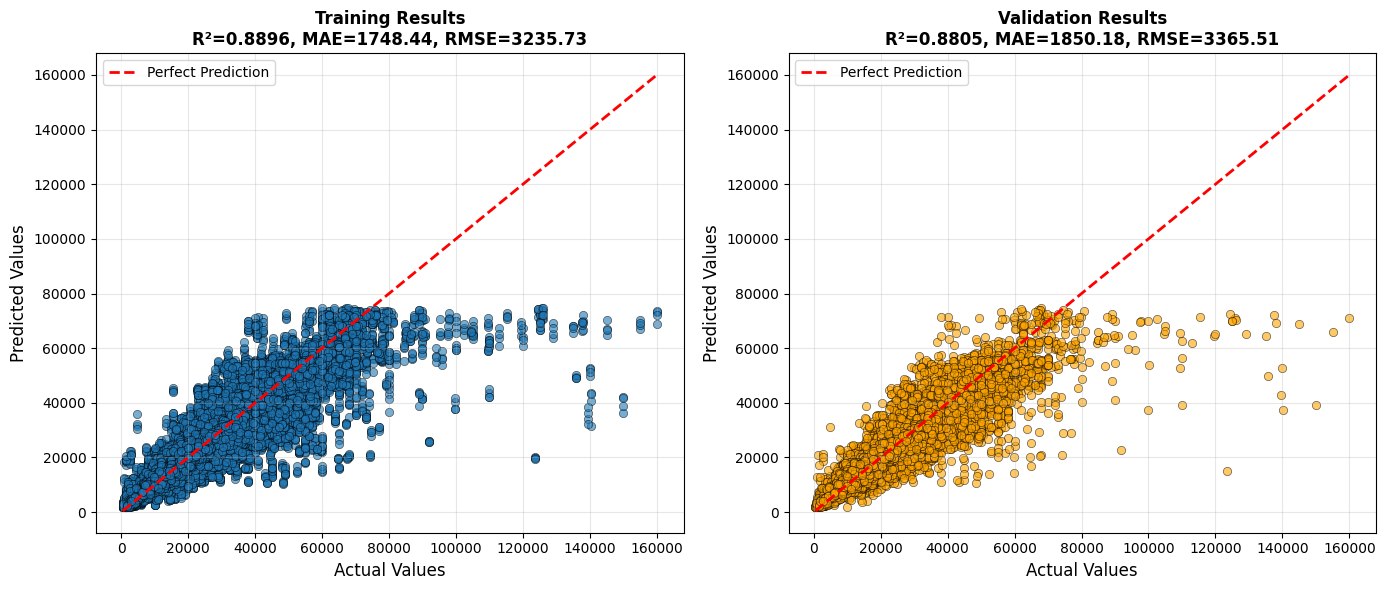

In [ ]:
evaluate_best_model_with_cv(RS_1st_run_model, X, y, cv=5)

# Delivery

In [ ]:
#best_model = random_search.best_estimator_

In [ ]:
#best_model.predict(X)


array([18214.59726606, 19436.74635258, 19363.97846042, ...,
       13213.51380654, 23101.50857853, 10346.43375815])